# Experiment No 6

## Aim:
To build K-Nearest Neighbor (KNN) and Support Vector Machine (SVM) classification models on the Glass Identification dataset and evaluate their performance using appropriate metrics.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Fetch Glass dataset (ID = 42)
glass = fetch_ucirepo(id=42)

# Combine features and target
df = pd.concat([glass.data.features, glass.data.targets], axis=1)

display(df.head())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Preprocessing

In [2]:
# Separate features and target
X_data = df.drop(columns=['Type_of_glass'])
y_data = df['Type_of_glass']

# Encode target labels (multiclass)
encoder = LabelEncoder()
y_data = encoder.fit_transform(y_data)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## KNN – Optimal K Selection

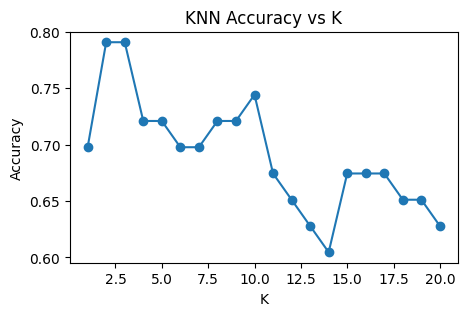

Best K: 2


In [3]:
k_range = range(1, 21)

k_scores = [
    KNeighborsClassifier(n_neighbors=k)
    .fit(X_train_scaled, y_train)
    .score(X_test_scaled, y_test)
    for k in k_range
]

plt.figure(figsize=(5,3))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.show()

best_k = k_range[np.argmax(k_scores)]
print("Best K:", best_k)

## KNN – Train & Evaluate

In [4]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

metrics_knn = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_knn, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_knn, average='weighted')],
    'F1-Score':  [f1_score(y_test, y_pred_knn, average='weighted')]
}).round(4)

display(metrics_knn)

print(classification_report(y_test, y_pred_knn))

,Accuracy,Precision,Recall,F1-Score
0,0.7907,0.8129,0.7907,0.7824


              precision    recall  f1-score   support

           0       0.76      0.93      0.84        14
           1       0.75      0.80      0.77        15
           2       1.00      0.33      0.50         3
           3       0.67      0.67      0.67         3
           4       1.00      0.50      0.67         2
           5       1.00      0.83      0.91         6

    accuracy                           0.79        43
   macro avg       0.86      0.68      0.73        43
weighted avg       0.81      0.79      0.78        43



## Confusion Matrix – KNN

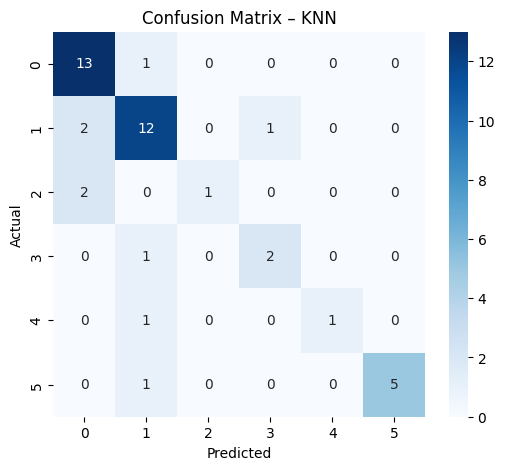

In [5]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_knn),
            annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix – KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SVM – Train & Evaluate

In [7]:
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

metrics_svm = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)],
    'Recall':    [recall_score(y_test, y_pred_svm, average='weighted')],
    'F1-Score':  [f1_score(y_test, y_pred_svm, average='weighted')]
}).round(4)

display(metrics_svm)

print(classification_report(y_test, y_pred_svm, zero_division=0))

,Accuracy,Precision,Recall,F1-Score
0,0.6977,0.7368,0.6977,0.7119


              precision    recall  f1-score   support

           0       0.75      0.64      0.69        14
           1       0.77      0.67      0.71        15
           2       0.17      0.33      0.22         3
           3       1.00      1.00      1.00         3
           4       0.50      0.50      0.50         2
           5       0.86      1.00      0.92         6

    accuracy                           0.70        43
   macro avg       0.67      0.69      0.68        43
weighted avg       0.74      0.70      0.71        43



## Confusion Matrix – SVM

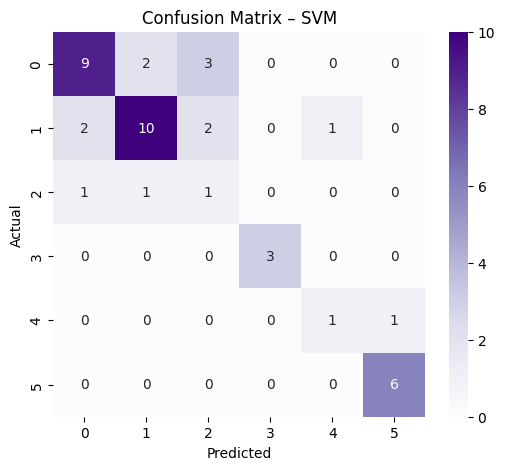

In [8]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d', cmap='Purples')

plt.title('Confusion Matrix – SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()